In [15]:
%matplotlib inline 

**Todo**
- verify splines coordinates (start at 0 or start at "top"?) x
- verify simulation times (start / end times)
- set up sources to fire later in time (start time different)
- possibly set up mesh in simpler way
- work witf functions for easier debugging

In [16]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_weighted_sub" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [17]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-07-07 14:03:38,589] INFO: Loading project from simulation_wavefield_custom_stf_weighted_sub.


In [18]:


# Simulation constants
f0 = 20.0
sampling_rate = 10000.0
dt = 1.0 / sampling_rate

step =0.1
x_positions = np.arange(30.0, 270.0, step)
# target_vprop = 1.6*67.9366 # supershear: 1.6*vs, according to trottet et al, 2022
target_vprop = 0.6*67.9366 # sub-rayleigh: 0.6*vs, according to trottet et al, 2022
delay_between_sources = step / target_vprop
print(f"Time step between sources: {delay_between_sources:.4f} s")

y_src = 2.625

# Shared time setup (half width can be the same for all the wavelets )
half_width = 0.08
pre_delay = half_width

last_source_delay = (len(x_positions) - 1) * delay_between_sources
t_max = pre_delay + last_source_delay + half_width + 0.5
t_sim = np.arange(0, t_max, dt)
print(f"t_sim length: {len(t_sim)} samples, duration: {t_sim[-1]:.3f} s")

t_local = np.arange(-half_width, half_width, dt)
half_samples = len(t_local) // 2

# Define Bases of wavelets
# Ricker 
ricker_base = (
    (1.0 - 2.0 * (np.pi * f0 * t_local) ** 2)
    * np.exp(-((np.pi * f0 * t_local) ** 2))
)

# # Morlet
# morlet_base = (
#     np.exp(-((t_local / half_width) ** 2)) 
#     * np.cos(2 * np.pi * f0 * t_local)
# )

# # Gaussian
# gaussian_base = np.exp(-((t_local / half_width) ** 2))


# Weigths setup
base_mxx =  1.0
base_myy = -1.0
base_mxy =  1.0

srcs = []

N_taper = int(half_width / delay_between_sources) + 1# taper over exactly one wavelet-width worth of sources
print(f"Tapering first {N_taper} sources")

taper = np.ones(len(x_positions))
taper[:N_taper] = np.hanning(2 * N_taper)[:N_taper] # rising half of Hanning window: for first source, it needs to be ramped up
taper[-N_taper:] = np.hanning(2 * N_taper)[N_taper:] # for last source, needs to be ramped down 

random_weight_xx = taper.copy()
random_weight_yy = taper.copy()
random_weight_xy = taper.copy()
weight_array = np.array([random_weight_xx, random_weight_yy, random_weight_xy]).T

# Main source setup
for i, x_src in enumerate(x_positions):
    center_time = pre_delay + i * delay_between_sources
    center_sample = int(round(center_time * sampling_rate))

    start_idx = center_sample - half_samples
    end_idx   = center_sample + half_samples

    # Initialize empty arrays for the delayed wavelets
    ricker_delayed = np.zeros(len(t_sim))
    # morlet_delayed = np.zeros(len(t_sim))
    # gaussian_delayed = np.zeros(len(t_sim))

    if end_idx > 0 and start_idx < len(t_sim):
        sim_start = max(0, start_idx)
        sim_end   = min(len(t_sim), end_idx)
        wav_start = max(0, -start_idx)
        wav_end   = wav_start + (sim_end - sim_start)
        
        # Shift all three wavelets into the simulation time window
        ricker_delayed[sim_start:sim_end]   = ricker_base[wav_start:wav_end]


    # Sanity check for clipping (we only need to check one since they share dimensions)
    n_nonzero = np.count_nonzero(ricker_delayed)
    expected  = len(ricker_base)
    if n_nonzero < expected - 2:
        print(f"  WARNING source {i}: only {n_nonzero}/{expected} samples written - wavelets clipped!")

    # Construct stf array
    stf_vector_array = np.array([
        ricker_delayed   * (base_mxx * weight_array[i, 0]),
        ricker_delayed   * (base_myy * weight_array[i, 1]),
        ricker_delayed   * (base_mxy * weight_array[i, 2])
    ])

    # stf setup
    stf = sc.stf.Custom.from_array(
        array=stf_vector_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=0.0, 
    )

    # plotting_steps = np.arange(0, len(x_positions), 5)
    # if i in plotting_steps:
    #     print(f"Source {i} at x={x_src:.1f} m | delay={center_time:.4f} s | "
    #           f"weight xx:{weight_array[i,0]:.4f} yy:{weight_array[i,1]:.4f} xy:{weight_array[i,2]:.4f}")
        
       
        # stf.plot()
        # display(plt.gcf())
        # plt.close()

    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x_src,
        y=y_src,
        mxx=1.0,
        myy=1.0,
        mxy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)

print(f"\nGenerated {len(srcs)} sources.")
print(f"First source centred at: {pre_delay:.4f} s")
print(f"Second source centred at: {pre_delay + delay_between_sources:.4f} s")
print(f"Last  source centred at: {pre_delay + (len(srcs)-1)*delay_between_sources:.4f} s")
print(f"t_sim spans 0 to {t_sim[-1]:.3f} s")

Time step between sources: 0.0025 s
t_sim length: 65454 samples, duration: 6.545 s
Tapering first 33 sources

Generated 2400 sources.
First source centred at: 0.0800 s
Second source centred at: 0.0825 s
Last  source centred at: 5.9654 s
t_sim spans 0 to 6.545 s


In [19]:
import h5py

iii=1
h5_path = srcs[iii].source_time_function.filename
dataset_name = srcs[iii].source_time_function.dataset_name
wavelet_type = srcs[iii].source_time_function.wavelet

print(f"Wavelet Type: {wavelet_type}")
print(f"HDF5 File Location: {h5_path}")
print(f"Dataset Name inside HDF5: {dataset_name}\n")

# Open  file to look at the raw custom wavelet data structure
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    
    print("--- Dataset Details ---")
    print("Array Shape (n_components, n_samples):", dset.shape)
    print("Data Type:", dset.dtype)
    
    print("\n--- Meta-Data Attributes Attached by Salvus ---")
    for key, val in dset.attrs.items():
        print(f"  {key}: {val}")
        
    # first 10 numerical values of the actual wavelet array
    print("\nFirst 10 amplitude values of the custom array:")
    print(dset[:10,0])
    print(dset[:10,1])
    print(dset[:10,2])



    

Wavelet Type: custom
HDF5 File Location: /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607071403619507eb40c605__1583861/custom_stf.h5
Dataset Name inside HDF5: /stf

--- Dataset Details ---
Array Shape (n_components, n_samples): (65454, 3)
Data Type: float64

--- Meta-Data Attributes Attached by Salvus ---
  sampling_rate_in_hertz: 10000.0
  start_time_in_seconds: 0.0

First 10 amplitude values of the custom array:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[-0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [20]:
srcs

[{'location': [30.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__26070714036142030fd1550c__1583861/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [30.1, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607071403619507eb40c605__1583861/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [30.200000000000003, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607071403623926709c6862__1583861/custom_stf.h5',
                           'wavelet': 'custom'},
  's

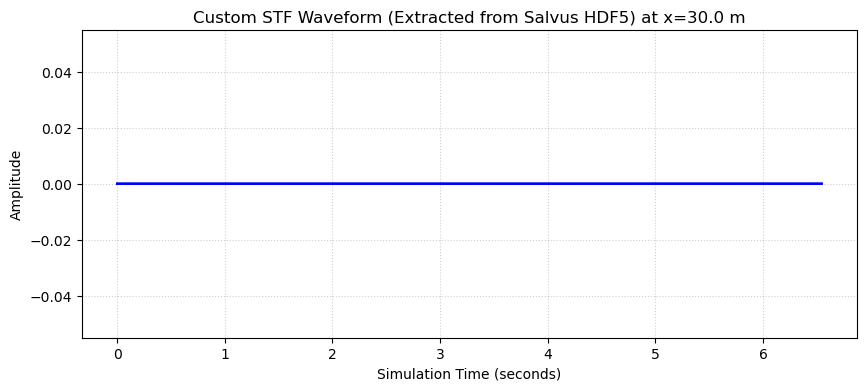

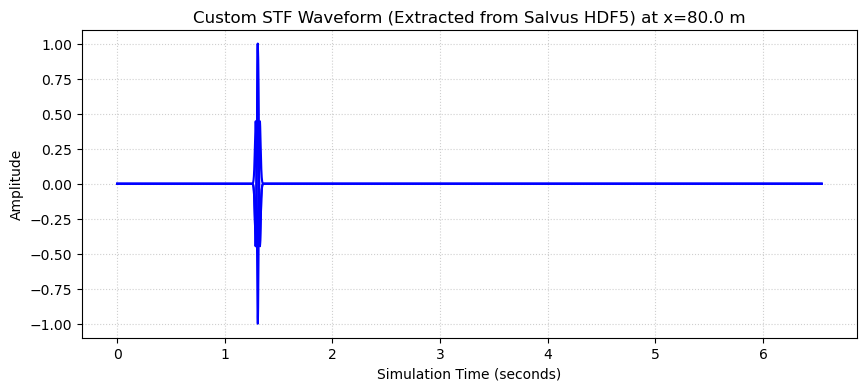

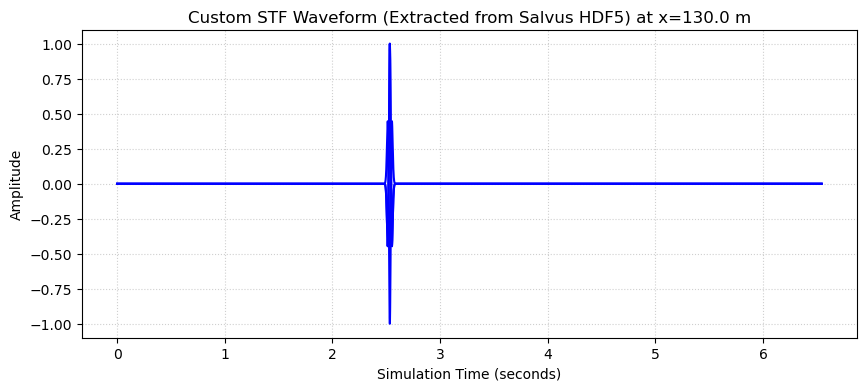

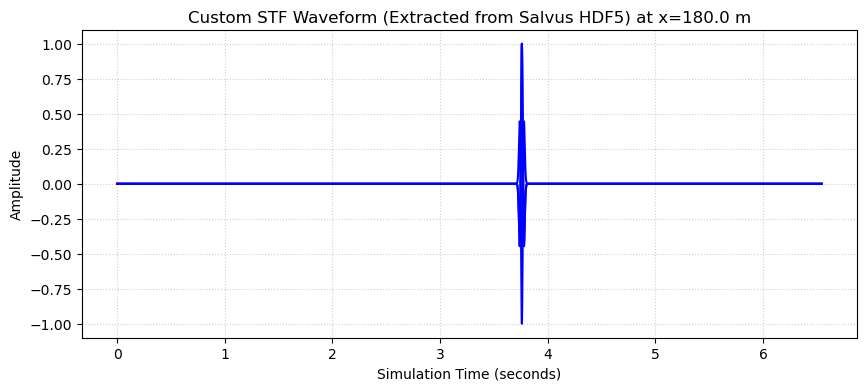

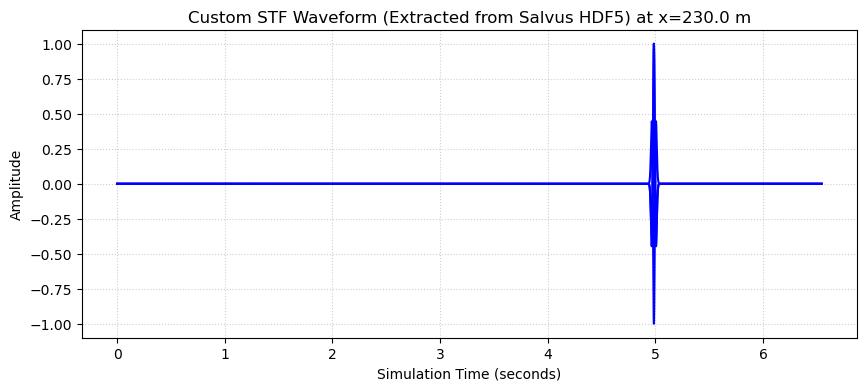

In [ ]:
# plotting 5 sample sources accross the domain
plotting_steps = np.arange(0, len(x_positions), 500)

for i in plotting_steps:
    # Path and dataset pointer form object for first source 
    h5_path = srcs[i].source_time_function.filename
    dataset_name = srcs[i].source_time_function.dataset_name

    # Extract the array and metadata from the HDF5 file
    with h5py.File(h5_path, 'r') as f:
        dset = f[dataset_name]
        stf_array = np.squeeze(dset[:]) # Squeeze removes empty dimensions 
        
        # Extract attributes
        sampling_rate = dset.attrs.get('sampling_rate_in_hertz', 10000.0)
        start_time = dset.attrs.get('start_time_in_seconds', 0.5)

    # Time axis of soutce 
    dt = 1.0 / sampling_rate
    time_axis = start_time + (np.arange(len(stf_array)) * dt)


    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, stf_array, color='blue', lw=1.5)
    plt.xlabel('Simulation Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title('Custom STF Waveform (Extracted from Salvus HDF5) at x={:.1f} m'.format(x_positions[i]))
    plt.grid(True, linestyle=':', alpha=0.6)
    display(plt.gcf())
    plt.close()

In [22]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).


x_min, x_max = 0.0, 400.0
# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([109.4, 109.4, 330.0]) 
vs = np.array([67.9366, 67.9366, 0.0])   
rho = np.array([250.0, 250.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

# Maximum frequency for meshing
# Phyiscical frequency of wavelet using fft
n_fft = len(ricker_base)
fft_vals = np.fft.rfft(ricker_base)
frequencies = np.fft.rfftfreq(n_fft, d=dt)
amplitude_spectrum = np.abs(fft_vals)

# Finding amplitude
cumulative_amplitude = np.cumsum(amplitude_spectrum)
total_amplitude = cumulative_amplitude[-1]

# Frequency where 95% of spactrum is contained
percentile_95_idx = np.where(cumulative_amplitude >= 0.95 * total_amplitude)[0][0]
max_frequency_source = frequencies[percentile_95_idx]
max_frequency = float(max_frequency_source)

print(f"Base Ricker Center Frequency (f0): {f0} Hz")
print(f"95th Percentile Source Frequency Content: {max_frequency:.1f} Hz")



# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

# calculating the wavelength of the center freqnecy (lambda = v / f)
wavelengths = slowest_velocities[0] / 20
print(f"Calculated minimum thickness for ABC: {wavelengths} m") # Absorbing boundary should be at least 3.5 wavelengths 


mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2.5,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    # absorbing_boundaries=(["x0", "x1", "y0"], 2.8), # check this with the printed code below
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")

# calculating how wide one element in the mesh is
# first disrtance between two nodes in the x direction
node_distances = np.sqrt(np.sum(np.diff(nodes, axis=0)**2, axis=1))
average_node_distance = np.mean(node_distances)
print(f"Average node distance in the mesh: {average_node_distance:.2f} m")

# there should be 3.5 times the wavelength thickness in the abc
abc_thickness = wavelengths * 3.5
print(f"Recommended ABC thickness based on wavelength: {abc_thickness:.2f} m")
# translating this to number of elements: abc_thickness / average_node_distance
abc_thickness_in_elements = abc_thickness / average_node_distance
print(f"Recommended ABC thickness in number of elements: {abc_thickness_in_elements:.1f} elements")



Base Ricker Center Frequency (f0): 20.0 Hz
95th Percentile Source Frequency Content: 37.5 Hz
Calculated minimum thickness for ABC: 7.5 m
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=68 m/s
  Weak layer: y = [2.25, 1.50] m, vs=68 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s
Average node distance in the mesh: 7.98 m
Recommended ABC thickness based on wavelength: 26.25 m
Recommended ABC thickness in number of elements: 3.3 elements


In [23]:
# Extract node coordinates for the entire mesh
# nodes_all shape is (num_elements, num_nodes_per_element, 2)
nodes_all = mesh.get_element_nodes()

# The region field tags your layers from top to bottom (0, 1, 2)
regions = mesh.elemental_fields["region"]

# 0: Snow, 1: Slab/Weak Layer, 2: Air
layer_names = ["Snow", "Slab/Weak Layer", "Air"]

print("--- Verifying Physical Layer Boundaries ---")
for i, name in enumerate(layer_names):
    # Find all elements belonging to this specific layer
    element_indices = np.where(regions == i)[0]
    
    if len(element_indices) == 0:
        print(f"{name}: No elements found (Layer missing!)")
        continue
        
    # Extract just the y-coordinates (index 1) for the nodes in this region
    # We look at the core physical elements, ignoring the padded ABC regions if possible,
    # but the max/min of the core regions will still respect your spline boundaries.
    y_coords = nodes_all[element_indices, :, 1]
    
    max_y = np.max(y_coords)
    min_y = np.min(y_coords)
    
    print(f"{name} Region ({i}):")
    print(f"  Maximum y-coordinate: {max_y:.2f} m")
    print(f"  Minimum y-coordinate: {min_y:.2f} m")

--- Verifying Physical Layer Boundaries ---
Snow Region (0):
  Maximum y-coordinate: 3.00 m
  Minimum y-coordinate: 2.25 m
Slab/Weak Layer Region (1):
  Maximum y-coordinate: 2.25 m
  Minimum y-coordinate: 1.50 m
Air Region (2):
  Maximum y-coordinate: 1.50 m
  Minimum y-coordinate: 0.00 m


In [24]:
iii=0
srcs[iii].source_time_function

{'dataset_name': '/stf',
 'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__26070714036142030fd1550c__1583861/custom_stf.h5',
 'wavelet': 'custom'}

In [ ]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 3.0
sim.physics.wave_equation.start_time_in_seconds = 0.0

abc_sides = sc.boundary.Absorbing(
    width_in_meters=float(abc_thickness), 
    side_sets=["x0", "x1"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True
)

abc_bottom = sc.boundary.Absorbing(
    width_in_meters=1.0, 
    side_sets=["y0"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True
)

sim.physics.wave_equation.boundaries = [abc_sides, abc_bottom]

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")


Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_weighted_sub/custom_job_moving_source_all_sources


In [28]:
sim.get_dictionary()

{'domain': {'dimension': 2,
  'polynomial_order': 4,
  'mesh': {'filename': '__SALVUS_FLOW_SPECIAL_TEMP__', 'format': 'hdf5'},
  'model': {'filename': '__SALVUS_FLOW_SPECIAL_TEMP__', 'format': 'hdf5'},
  'geometry': {'filename': '__SALVUS_FLOW_SPECIAL_TEMP__', 'format': 'hdf5'}},
 'output': {'meta_data': {'meta_json_filename': 'meta.json',
   'progress_json_filename': 'progress.json'},
  'volume_data': {'filename': 'volume_data_output.h5',
   'format': 'hdf5',
   'fields': ['displacement', 'velocity'],
   'sampling_interval_in_time_steps': 50}},
 'physics': {'wave_equation': {'time_stepping_scheme': 'newmark',
   'start_time_in_seconds': -0.2,
   'end_time_in_seconds': 3.0,
   'courant_number': 0.6,
   'attenuation': False,
   'point_source': [{'location': [30.0, 2.625],
     'spatial_type': 'moment_tensor',
     'spatial_weights': [1.0, 1.0, 1.0],
     'source_time_function': {'dataset_name': '/stf',
      'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__2607071

In [29]:
sim

In [30]:

# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

SalvusJob `job_2607071406392885_401d934ec3` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/6987 [00:00<?, ?it/s]

* Downloaded 36.9 MB of results to `simulation_wavefield_custom_stf_weighted_sub/custom_job_moving_source_all_sources`.
* Total run time: 11.35 seconds.
* Pure simulation time: 4.03 seconds.
Run finished successfully!


In [31]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-07 14:07:16,644] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_custom_stf_weighted_sub/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 141, c: 2, x: 1601, y: 101)> Size: 182MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],



Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 3.0059539144124803
vx shape: (141, 1601)
vy shape: (141, 1601)


/tmp/ipykernel_1583861/1095561471.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1583861/1095561471.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


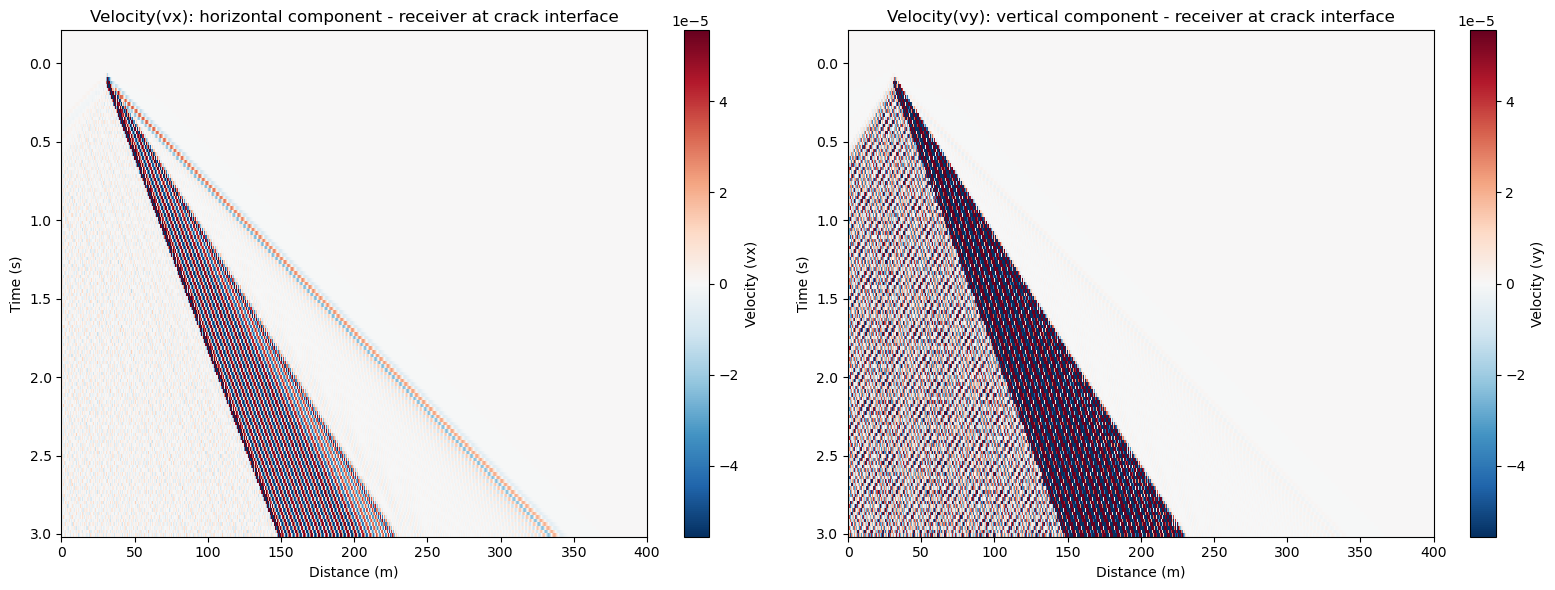

In [32]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [33]:
# displacemnt and strain
moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
# Extract displacement wavefield output from the single combined run.
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

print(f"WavefieldOutput shape: {dis_wo.data.shape}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)
print("WavefieldOutput shape:", dis_wo.data.shape)#
print("xarray shape:", dis_2d_layered.shape) 

# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)


Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-07-07 14:07:57,389] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_custom_stf_weighted_sub/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 141, c: 2, x: 1601, y: 101)> Size: 182MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,       

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 3.0059539144124803
vx shape: (141, 1601)
vy shape: (141, 1601)


/tmp/ipykernel_1583861/4079888971.py:58: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1583861/4079888971.py:80: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


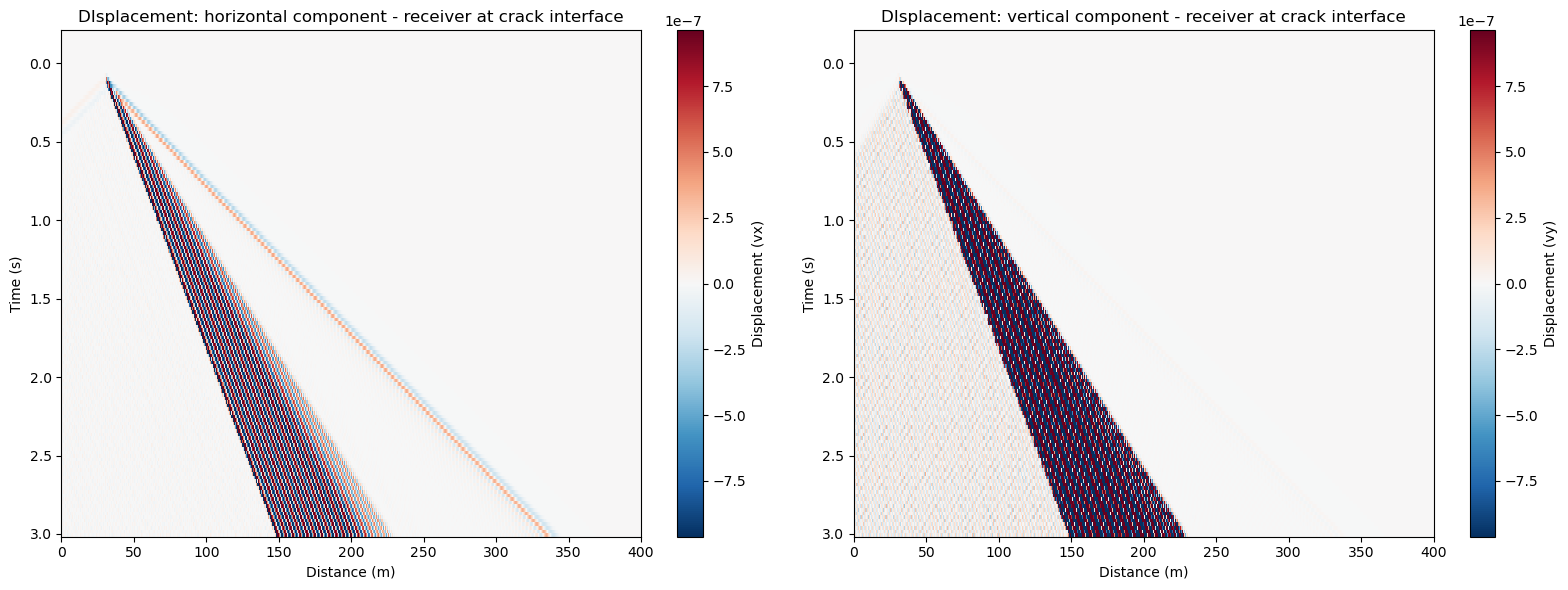

In [34]:
# plotting displacement
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
dis_vx = dis_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
dis_vy = dis_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in dis_vx.dims:
    dis_vx_plot = dis_vx.mean(dim=e_name)
    dis_vy_plot = dis_vy.mean(dim=e_name)
else:
    dis_vx_plot = dis_vx
    dis_vy_plot = dis_vy

# Ensure plotting order is (time, x)
dis_vx_plot = dis_vx_plot.transpose(t_name, x_name)
dis_vy_plot = dis_vy_plot.transpose(t_name, x_name)

t_vals = dis_vx_plot[t_name].values
x_line = dis_vx_plot[x_name].values
data_vx = dis_vx_plot.values
data_vy = dis_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)
#vmax = 1e-7

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("DIsplacement: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Displacement (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("DIsplacement: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Displacement (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.2 -> 3.0059539144124803
vx shape: (141, 1601)
vy shape: (141, 1601)


/tmp/ipykernel_1583861/2342594202.py:60: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_1583861/2342594202.py:82: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


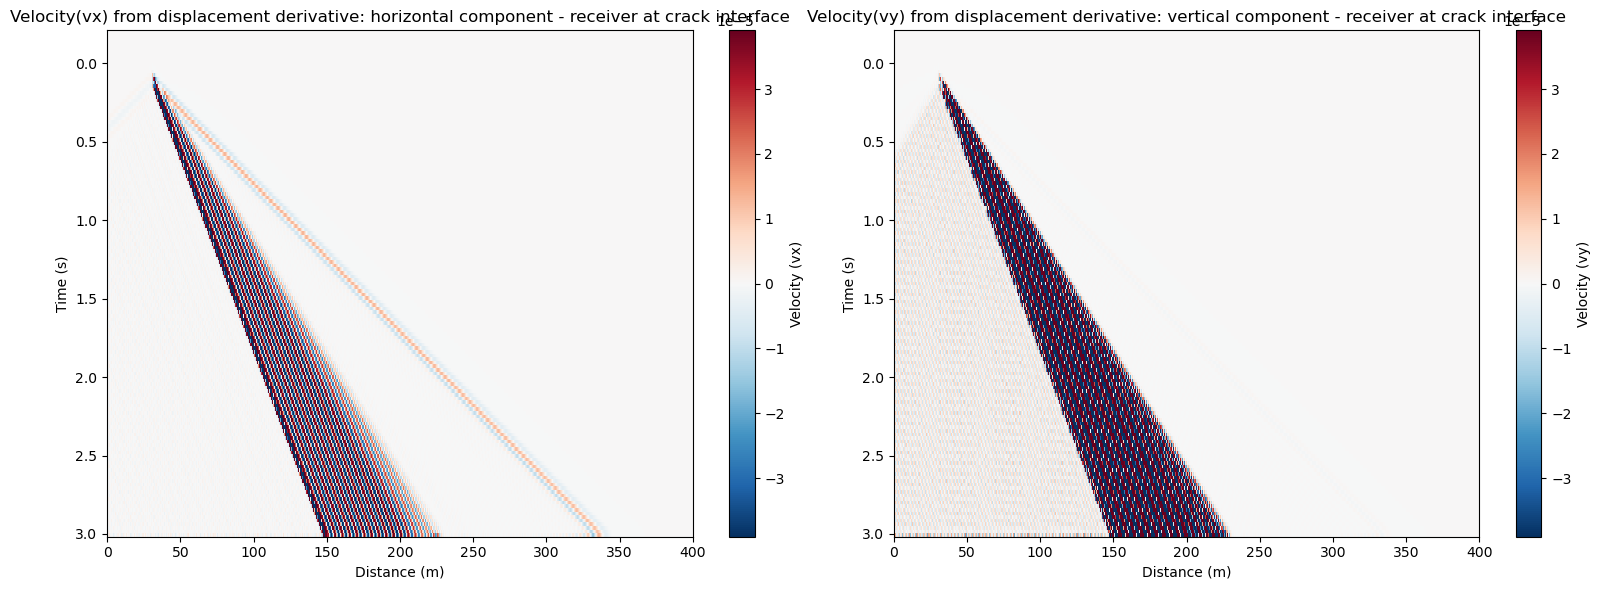

In [35]:
# instead of velocity: temporal derivative of displacement to get velocity
dis_2d_layered_dt = dis_2d_layered.differentiate(t_name)

# plotting displacement temporal derivative (velocity)
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(dis_2d_layered_dt.coords)
dims_set = set(dis_2d_layered_dt.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={dis_2d_layered_dt.dims}, coords={list(dis_2d_layered_dt.coords)}")

# Select both components at y receiver line
sg_vx = dis_2d_layered_dt.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = dis_2d_layered_dt.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx) from displacement derivative: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy) from displacement derivative: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

rupture speed taken is 40.761959999999995 m/s


/tmp/ipykernel_1583861/84135321.py:61: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  ax.pcolormesh(


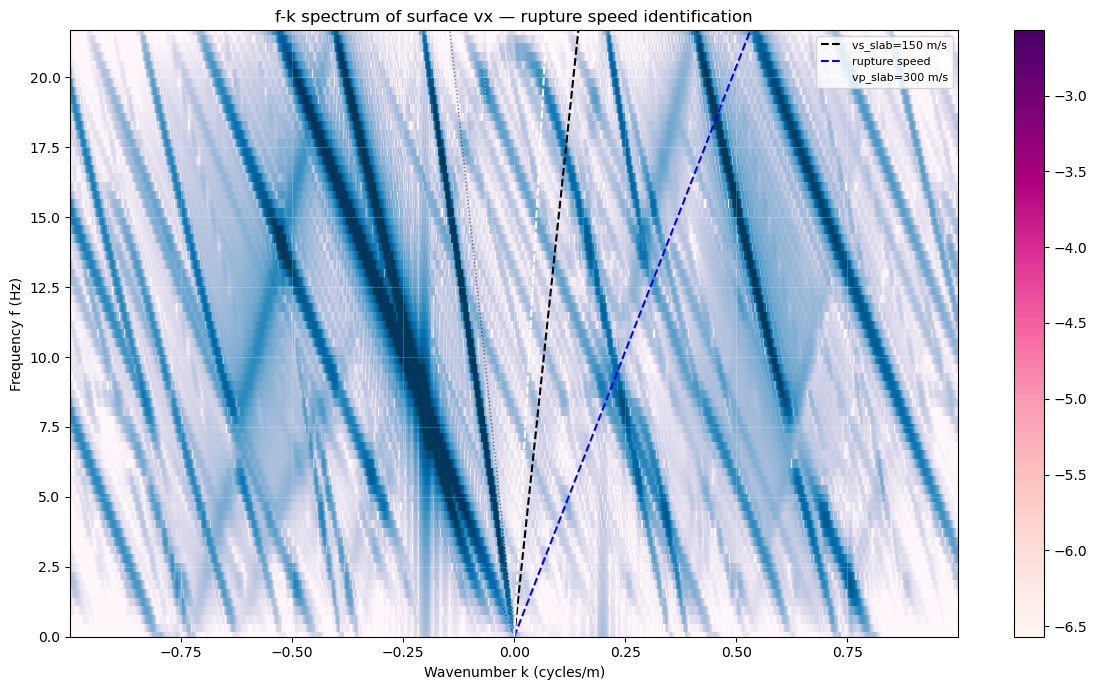

Interpretation:
Energy aligned with 'rupture speed' line -> correct rupture kinematics
Energy at vs_slab line -> S-wave cone (supershear: ahead of rupture front)
Energy at vrayleigh_slab line -> Rayleigh wave train behind crack tip


In [36]:
# Frequency domain analysis  f-k analysis- identify rupture speed and Mach cone
# print rupture speed to verify
print(f"rupture speed taken is {target_vprop} m/s")
# surface shot gather: gather (same as waterfall)
# Using vx (horizontal) at the slab surface — most sensitive to crack
y_recv  = 1.5   # snow surface in your coordinates
x_array = np.linspace(0, 400, 401)

sg = dis_2d_layered_dt.sel(
    {y_name: y_recv},
    method="nearest"
).isel({c_name: 0}) # vx component

t_vals  = sg[t_name].values
x_vals  = sg[x_name].values
data    = sg.values # shape (nt, nx) or (nx, nt

# Ensure shape is (nt, nx)
if data.shape[0] == len(x_vals):
    data = data.T

dt = float(np.diff(t_vals).mean())
dx = float(np.diff(x_vals).mean())
nt, nx = data.shape

# 2D FFT - f-k spectrum
# Taper in both dimensions to reduce spectral leakage
taper_t = np.hanning(nt)
taper_x = np.hanning(nx)
data_tapered = data * taper_t[:, None] * taper_x[None, :]

fk = np.fft.fftshift(np.fft.fft2(data_tapered))
freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
wns   = np.fft.fftshift(np.fft.fftfreq(nx, dx)) # wavenumber (cycles/m)

# Only plot positive frequencies
f_pos  = freqs >= 0
fk_pos = fk[f_pos, :]
f_plot = freqs[f_pos]

# Theoretical velocity lines to overlay
def velocity_line(v, freqs, wns):
    """k = f/v line in f-k space."""
    return freqs / v # k values for each frequency

velocities = {
    "vs_slab=150 m/s": 150.0,
    #"vrayleigh_slab=140 m/s": 140.0, # Rayleigh speed ≈ 0.92*vs
    "rupture speed": target_vprop,
    "vp_slab=300 m/s": 300.0,
}
colors = ["black", "blue", "white", "green"]

fig, ax = plt.subplots(figsize=(12, 7))

# f-k power (log scale)
pk = np.log10(np.abs(fk_pos) + 1e-10)
vmax_pk = np.percentile(pk, 99)
vmin_pk = vmax_pk - 4 # 4 decades of dynamic range

ax.pcolormesh(
    wns, f_plot, pk,
    shading="none", cmap="PuBu",
    vmin=vmin_pk, vmax=vmax_pk,
)

# Overlay velocity lines: f = v*k → k = f/v
k_max = wns.max()
for (label, v), col in zip(velocities.items(), colors):
    k_line = f_plot / v
    mask = np.abs(k_line) <= k_max
    ax.plot(k_line[mask], f_plot[mask], color=col, lw=1.5,
            linestyle="--", label=label)
    # Also negative k (retrograde branch)
    ax.plot(-k_line[mask], f_plot[mask], color=col, lw=1.0,
            linestyle=":", alpha=0.5)

ax.set_xlim(-k_max * 0.5, k_max * 0.5)
ax.set_ylim(0, min(3 * f0, freqs.max()))
ax.set_xlabel("Wavenumber k (cycles/m)")
ax.set_ylabel("Frequency f (Hz)")
ax.set_title("f-k spectrum of surface vx — rupture speed identification")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.2, color="white")

# Plot colorbar for energy 
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap="RdPu", norm=plt.Normalize(vmin=vmin_pk, vmax=vmax_pk)),
    ax=ax
)

plt.tight_layout()
display(fig)
plt.close(fig)

print("Interpretation:")
print("Energy aligned with 'rupture speed' line -> correct rupture kinematics")
print("Energy at vs_slab line -> S-wave cone (supershear: ahead of rupture front)")
print("Energy at vrayleigh_slab line -> Rayleigh wave train behind crack tip")